In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *

# To rewrite old "save_B.txt" into the new version

In [2]:
# for n in range(1,31):

input_file = '/data1/DATA_Duplat/Brut/Test/Te9n1/save_B.txt'
# Lire le fichier d'entrée
with open(input_file, 'r') as file:
    lines = file.readlines()

# Variables pour stocker les valeurs
zF = None
stackzF = None
data_lines = []

# Traiter les lignes
for line in lines:
    if '#zF' in line:
        zF = float(line.split()[0])
        zfline = f"2  #zF\n"
        data_lines.append(zfline)  # Ajouter la ligne #zF
    elif '#Seed' in line:
        # Ajouter la ligne avec la modification
        if zF is not None:
            stackzF = zF -2
            new_line = f"{zF - 2:.6f}  #StackzF\n"
            data_lines.append(new_line)
        data_lines.append(line)  # Ajouter la ligne #Seed
    else:
        # data_lines.append(line)  # Ajouter les autres lignes
        if stackzF is not None:
            # Traiter les lignes de données
            parts = line.split()
            if len(parts) == 3:
                # Soustraire StackzF de la troisième colonne
                parts[2] = f"{float(parts[2]) - stackzF:.6f}"
                modified_line = "  ".join(parts) + "\n"
                data_lines.append(modified_line)
            else:
                data_lines.append(line)
        else:
            data_lines.append(line)

output_file = '/data1/DATA_Duplat/Brut/Test/Te9n1/save_B_bis.txt'
# Écrire les données modifiées dans un nouveau fichier
with open(output_file, 'w') as file:
    file.writelines(data_lines)
    
""" 
# Lire le fichier d'entrée
with open(output_file, 'r') as file:
    lines = file.readlines()

# Trouver la valeur de StackzF
stackzF = None
data_lines = []

# Traiter les lignes
for line in lines:
    if '#StackzF' in line:
        stackzF = float(line.split()[0])
        data_lines.append(line)
    elif '#Seed' in line:
        # Ajouter la ligne #Seed sans modification
        data_lines.append(line)
    else:
        if stackzF is not None:
            # Traiter les lignes de données
            parts = line.split()
            if len(parts) == 3:
                # Soustraire StackzF de la troisième colonne
                parts[2] = f"{float(parts[2]) - stackzF:.6f}"
                modified_line = "  ".join(parts) + "\n"
                data_lines.append(modified_line)
            else:
                data_lines.append(line)
        else:
            data_lines.append(line)

# Écrire les données modifiées dans un nouveau fichier
with open(output_file, 'w') as file:
    file.writelines(data_lines) 
 """

' \n# Lire le fichier d\'entrée\nwith open(output_file, \'r\') as file:\n    lines = file.readlines()\n\n# Trouver la valeur de StackzF\nstackzF = None\ndata_lines = []\n\n# Traiter les lignes\nfor line in lines:\n    if \'#StackzF\' in line:\n        stackzF = float(line.split()[0])\n        data_lines.append(line)\n    elif \'#Seed\' in line:\n        # Ajouter la ligne #Seed sans modification\n        data_lines.append(line)\n    else:\n        if stackzF is not None:\n            # Traiter les lignes de données\n            parts = line.split()\n            if len(parts) == 3:\n                # Soustraire StackzF de la troisième colonne\n                parts[2] = f"{float(parts[2]) - stackzF:.6f}"\n                modified_line = "  ".join(parts) + "\n"\n                data_lines.append(modified_line)\n            else:\n                data_lines.append(line)\n        else:\n            data_lines.append(line)\n\n# Écrire les données modifiées dans un nouveau fichier\nwith open

# To check what's inside .gz

In [ ]:
n = 100
skiprows = 0
data = read_gz_with_pandas_nrows("/data1/DATA_Duplat/Brut/PDF/PD12n14/Avalanche_outputB.gz", nrows = int(n), skiprows=skiprows)
# data = read_gz_with_pandas("/data1/DATA_Duplat/Brut/Test/Te6n1/random_random.gz")
    

print(data)

[['zF' '+' 'StackzF,' ... 1.0 1.0 37943.0]
 ['6.53693e+07' '1' '43272' ... nan nan nan]
 ['6.53693e+07' '1' '37942' ... nan nan nan]
 ...
 ['6.53693e+07' '1' '8381' ... nan nan nan]
 ['6.53693e+07' '1' '2119' ... nan nan nan]
 ['6.53693e+07' '1' '6588' ... nan nan nan]]


In [10]:
with gzip.open("/data1/DATA_Duplat/Brut/Memory_effects/Me83n2/random_random.gz", "rt") as f:
    for i, line in enumerate(f) :
        print(line)
        if i == 10: 
            break
    # first_line = f.readline()
    # second_line = f.readline()
    # print(first_line)
    # print(second_line)

#Nav  zF  Stack_zF  nin  S  Newnin  NewS  nbtry  s_max_5  s_max_4  s_max_3  s_max_2  s_max_1  s_mean

126347  2.13779  5141.01  4669  1  -1  -1  1637  9  10  10  15  22  1.13736

250273  3.49107  5145.66  453  2  -1  -1  1637  66  66  67  67  67  1.37118

366104  4.49019  5150.66  16328  3  -1  -1  1637  8  8  8  8  9  1.11477

487451  5.18581  5155.96  15735  1  -1  -1  1637  54  54  54  55  55  1.38706

614029  1.5977  5165.55  15042  1  -1  -1  1637  83  83  83  83  84  1.45788

747778  3.09701  5170.05  14003  1  -1  -1  1637  8  8  9  13  17  1.15934

879253  4.56523  5174.58  12818  1  -1  -1  1637  22  22  22  23  24  1.23871

1011674  1.51361  5183.64  12946  1  -1  -1  1637  191  191  192  192  192  2.68742

1141127  2.93104  5188.22  13074  1  -1  -1  1637  33  33  41  42  43  1.36142

1266904  4.10299  5193.05  4933  1  -1  -1  1637  6  6  7  7  7  1.12393



# To check what's inside Avalanche_outputB.txt


In [4]:
# Ouvrir le fichier et lire les 10 premières lignes avec readlines()
with open('/home/kduplat/Documents/Data/Brut/OFC*gaus/OF6n50/Avalanche_outputB.txt', 'r') as fichier:
    for i in range(10):
        line = fichier.readline()
        if line.strip().startswith('#'):
            continue
        if not line  :  # Si la ligne est vide, cela signifie que le fichier est plus court que 10 lignes
            break
        print(line)
        print(len(line.strip().split()))
        # print(ligne.strip().split())  # Afficher la ligne sans les espaces blancs à la fin

""" data = np.loadtxt('/data1/DATA_Duplat/Brut/DataML/Subbatch/Da1n1/Avalanche_outputB.txt')
print(len(data)) """

218878  1  16046  9.092e-06  1

5
218878  3  4233  8.439e-06  3

5
218878  1  3862  2.620e-05  1

5
218878  1  22811  4.122e-06  1

5
218878  1  32053  5.554e-06  1

5
218878  1  27529  3.393e-05  1

5
218878  7  2682  3.002e-06  7

5
218878  1  25221  1.753e-05  1

5
218878  3  32694  3.036e-06  3

5
218878  2  20899  8.591e-06  2

5


" data = np.loadtxt('/data1/DATA_Duplat/Brut/DataML/Subbatch/Da1n1/Avalanche_outputB.txt')\nprint(len(data)) "

# To check the snapshots of a folder

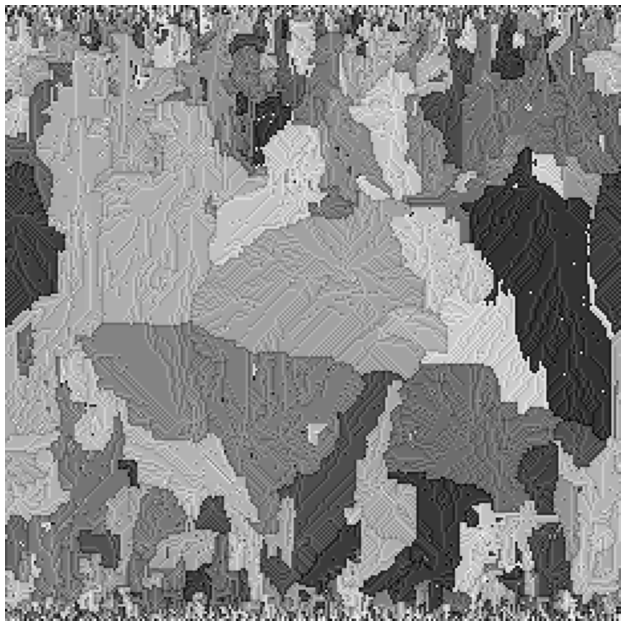

In [ ]:
# folderpath = "/data1/DATA_Duplat/Brut/Configurations/Co38n7"
# L2 = read_parameters(folderpath)[0]
# L1 = read_parameters(folderpath)[1]
# snapshots("{}/Snapshots".format(folderpath), L1, L2)



L1 = 256
L2 = 256
snapshotsbis(["/data1/DATA_Duplat/Brut/Correlation2/Co1n8/Snapshots/nav20000000000_outputB.txt",
              ], L1, L2, switch=0, sizeploth = 15, sizeplotw = 8)

# To extract parameters from files

In [ ]:
fnb = np.arange(1,15)
folderpath = [f'/data1/DATA_Duplat/Brut/PDF/PD1n{nb}' for nb in fnb]
Parameters = [read_parameters(folder)[2] for folder in folderpath]
print(Parameters)

In [ ]:
print(coorno(50844, 256))

# Snapshot from save file

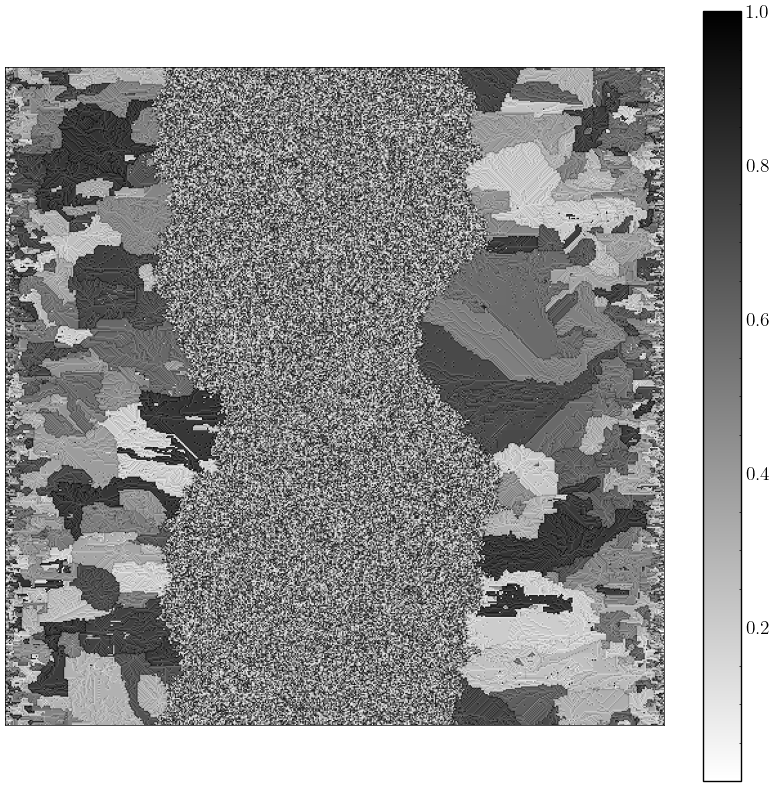

In [2]:
L1 = 512
L2 = 512

data = snapfromsave("/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp17n7/", L1, L2, 10, 10)

# Plot the correlation length over time



In [ ]:
folderpath ="/data1/DATA_Duplat/Brut/PDF/PD1n14"

params = read_parameters(folderpath)

print (params[15])
L1 = params[0]
L2 = params[0]
iniava = params[15][0]
deltaava = params[15][1]
nbava = 0

with open (f"{folderpath}/save_B.txt") as f:
    lines = f.readlines()
    
    for line in lines:
        if line.strip() == '' or line.strip().startswith('#'):
            continue
        
        match = re.match(r"([\d\.\+\-eE]+)\s+#Nav", line)
        if match :
            nbava = int(match.group(1))
            break

nbava = 1000000000000



clentab , avgtab = corrlength(folderpath, iniava, deltaava, nbava, L2, switch_plot = 1, numcol = 0)

clentabfit, avgtabfit, avgfitsmooth = corrlengthfit(folderpath, L2, iniava, deltaava, clentab, numcol = 3, switch_plot = 1)

#   Compare two .txt

In [13]:
file1 = "/data1/DATA_Duplat/Brut/Test/Te53n2/Snapshots/nav10000_outputB.txt"
file2 = "/data1/DATA_Duplat/Brut/Test/Te1n2/Snapshots/nav10000_outputB.txt"

with open(file1, 'r', encoding='utf-8') as f1, open(file2, 'r', encoding='utf-8') as f2:
    for line_num, (line1, line2) in enumerate(zip(f1, f2), start=1):
        if line1 != line2:
            print(f"Différence détectée à la ligne {line_num} :")
            print(f"Fichier 1 : {line1.strip()}")
            print(f"Fichier 2 : {line2.strip()}")
            break
    else:    
        print("Les fichiers sont identiques.")
    

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


# To change the Number of avalanches to 0 in a save file

In [6]:
# files = ["/data1/DATA_Duplat/Brut/Ava_track/Av5n{}/save_B.txt".format(j) for j in range(1, 15)]
# files = ["/data1/DATA_Duplat/Brut/Memory_effects/Me13n2/save_B.txt"]
files = ["/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp{}n{}/save_B.txt".format(i,j) for j in range(1,11) for i in [18,19,20,21]]


for filename in files:

        # lire toutes les lignes
        with open(filename, "r") as f:
            lines = f.readlines()

        # remplacer la 3ème ligne (index 2)
        if len(lines) >= 3:
            parts = lines[2].split("#")
            lines[2] = "0  #{}\n".format(parts[1].strip()) if len(parts) > 1 else "0\n"

        # réécrire le fichier
        with open(filename, "w") as f:
            f.writelines(lines)

        print(f"Modifié : {filename}")


Modifié : /data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp18n1/save_B.txt
Modifié : /data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp19n1/save_B.txt
Modifié : /data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp20n1/save_B.txt
Modifié : /data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp21n1/save_B.txt
Modifié : /data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp18n2/save_B.txt
Modifié : /data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp19n2/save_B.txt
Modifié : /data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp20n2/save_B.txt
Modifié : /data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp21n2/save_B.txt
Modifié : /data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp18n3/save_B.txt
Modifié : /data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp19n3/save_B.txt
Modifié : /data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp20n3/save_B.txt
Modifié : /data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp21n3/save_B.txt
Modifié : /data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp18n4/save_B.txt
Modifié : /data1/DATA_Dup

In [12]:
data = np.loadtxt("/data1/DATA_Duplat/Brut/Test/Te63n1/random_histo_si.txt")

print(np.sum(data, axis = 1))

[60. 58. 63. 71. 64. 50. 61. 57. 47. 75.]
